# 03b — Label & Save (fixed variant)

**Stage 3 of 3 (fixed).** Same as `03_label_and_save.ipynb` but uses `wesad_preprocess_fixed`.

Output: `data/preprocessed/WESAD_fixed/S{id}_clean.pkl`

In [1]:
import sys, gc, time
from pathlib import Path
HERE = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Scripts' / 'Preprocess').exists()) / 'Scripts' / 'Preprocess'
sys.path.insert(0, str(HERE))

import numpy as np
import pandas as pd
import wesad_preprocess_fixed as wp

DROP_EXCLUDED = True    # drop transient / meditation / ignore samples
SUBJECTS = wp.SUBJECT_IDS   # e.g. [2] to test on one subject first

## 1. Single-subject walkthrough

In [2]:
data = wp.load_subject(2)
bin700 = wp.relabel_binary(data['label'])
ids, counts = np.unique(bin700, return_counts=True)
print({int(i): int(c) for i, c in zip(ids, counts)}, '(-1 = excluded)')

filtered = wp.filter_subject(data)
clean = wp.build_clean_subject(data, filtered, drop_excluded=DROP_EXCLUDED)

rows = []
for loc in ('chest', 'wrist'):
    for name, arr in clean['signal'][loc].items():
        lab = clean['label'][loc][name]
        rows.append({'location': loc, 'signal': name, 'fs': clean['fs'][loc][name],
                     'samples': len(arr), 'stress_ratio': round(float(lab.mean()), 3)})
pd.DataFrame(rows)

{-1: 2770600, 0: 1054200, 1: 430500} (-1 = excluded)


,location,signal,fs,samples,stress_ratio
0,chest,ACC,700,1484700,0.29
1,chest,ECG,700,1484700,0.29
2,chest,EMG,700,1484700,0.29
3,chest,EDA,700,1484700,0.29
4,chest,EDA_SCR,700,1484700,0.29
5,chest,EDA_SCL,700,1484700,0.29
6,chest,Temp,700,1484700,0.29
7,chest,Resp,700,1484700,0.29
8,wrist,ACC,32,67872,0.29
9,wrist,BVP,64,135744,0.29


In [3]:
del data, filtered, clean; gc.collect()

0

## 2. Process & save all subjects

One subject at a time to limit RAM. Takes several minutes (chest EDA decomposition at 700 Hz is the slowest step).

In [4]:
summary = []
for sid in SUBJECTS:
    t0 = time.time()
    clean = wp.preprocess_subject(sid, drop_excluded=DROP_EXCLUDED, save=True)
    lab = clean['label']['chest']['ECG']
    summary.append({'subject': clean['subject'],
                    'minutes_kept': round(len(lab) / 700 / 60, 1),
                    'stress_ratio': round(float(lab.mean()), 3),
                    'seconds': round(time.time() - t0, 1)})
    print(summary[-1])
    del clean; gc.collect()

pd.DataFrame(summary)

{'subject': 'S2', 'minutes_kept': 35.4, 'stress_ratio': 0.29, 'seconds': 4.9}
{'subject': 'S3', 'minutes_kept': 35.9, 'stress_ratio': 0.297, 'seconds': 80.2}
{'subject': 'S4', 'minutes_kept': 36.1, 'stress_ratio': 0.293, 'seconds': 118.0}
{'subject': 'S5', 'minutes_kept': 37.0, 'stress_ratio': 0.291, 'seconds': 110.6}
{'subject': 'S6', 'minutes_kept': 36.7, 'stress_ratio': 0.295, 'seconds': 50.8}
{'subject': 'S7', 'minutes_kept': 36.6, 'stress_ratio': 0.291, 'seconds': 41.7}
{'subject': 'S8', 'minutes_kept': 36.8, 'stress_ratio': 0.303, 'seconds': 40.0}
{'subject': 'S9', 'minutes_kept': 36.6, 'stress_ratio': 0.294, 'seconds': 40.1}
{'subject': 'S10', 'minutes_kept': 38.0, 'stress_ratio': 0.318, 'seconds': 41.9}
{'subject': 'S11', 'minutes_kept': 37.1, 'stress_ratio': 0.305, 'seconds': 39.5}
{'subject': 'S13', 'minutes_kept': 37.1, 'stress_ratio': 0.298, 'seconds': 43.4}
{'subject': 'S14', 'minutes_kept': 37.1, 'stress_ratio': 0.303, 'seconds': 41.8}
{'subject': 'S15', 'minutes_kept': 3

,subject,minutes_kept,stress_ratio,seconds
0,S2,35.4,0.290,4.9
1,S3,35.9,0.297,80.2
2,S4,36.1,0.293,118.0
3,S5,37.0,0.291,110.6
4,S6,36.7,0.295,50.8
5,S7,36.6,0.291,41.7
6,S8,36.8,0.303,40.0
7,S9,36.6,0.294,40.1
8,S10,38.0,0.318,41.9
9,S11,37.1,0.305,39.5


## 3. Verify saved files

In [5]:
c = wp.load_clean_subject(SUBJECTS[0])
print('keys       :', list(c.keys()))
print('chest      :', list(c['signal']['chest'].keys()))
print('wrist      :', list(c['signal']['wrist'].keys()))
labels_found = set()
for loc in ('chest', 'wrist'):
    for name in c['signal'][loc]:
        assert len(c['signal'][loc][name]) == len(c['label'][loc][name]), (loc, name)
        labels_found |= set(np.unique(c['label'][loc][name]).tolist())
print('labels     :', labels_found)
print('files      :', sorted(p.name for p in wp.OUTPUT_DIR.glob('*_clean.pkl')))

keys       : ['subject', 'fs', 'signal', 'label', 'label_names', 'drop_excluded']
chest      : ['ACC', 'ECG', 'EMG', 'EDA', 'EDA_SCR', 'EDA_SCL', 'Temp', 'Resp']
wrist      : ['ACC', 'BVP', 'EDA', 'EDA_SCR', 'EDA_SCL', 'TEMP']
labels     : {0, 1}
files      : ['S10_clean.pkl', 'S11_clean.pkl', 'S13_clean.pkl', 'S14_clean.pkl', 'S15_clean.pkl', 'S16_clean.pkl', 'S17_clean.pkl', 'S2_clean.pkl', 'S3_clean.pkl', 'S4_clean.pkl', 'S5_clean.pkl', 'S6_clean.pkl', 'S7_clean.pkl', 'S8_clean.pkl', 'S9_clean.pkl']


## 4. Preview saved preprocessed data

Load one participant's `*_clean.pkl` and inspect the signals, labels, and a before/after comparison for every signal.

In [6]:
PREVIEW_SUBJECT = SUBJECTS[0]   # change to any processed subject id, e.g. 4
PREVIEW_SECONDS = 300            # length of the preview segment to plot
PREVIEW_START_S = 820           # seconds into the recording

raw = wp.load_subject(PREVIEW_SUBJECT)
clean = wp.load_clean_subject(PREVIEW_SUBJECT)

print(f"Subject {clean['subject']}  (drop_excluded={clean['drop_excluded']})")
print(f"label_names: {clean['label_names']}")

rows = []
for loc in ('chest', 'wrist'):
    for name, arr in clean['signal'][loc].items():
        arr = np.asarray(arr)
        lab = np.asarray(clean['label'][loc][name])
        rows.append({
            'location': loc,
            'signal': name,
            'fs_hz': clean['fs'][loc][name],
            'samples': arr.shape[0],
            'duration_min': round(arr.shape[0] / clean['fs'][loc][name] / 60, 1),
            'mean': round(float(arr.mean()), 4),
            'std': round(float(arr.std()), 4),
            'stress_ratio': round(float(lab.mean()), 3),
        })
pd.DataFrame(rows)

Subject S2  (drop_excluded=True)
label_names: {0: 'non-stress', 1: 'stress'}


,location,signal,fs_hz,samples,duration_min,mean,std,stress_ratio
0,chest,ACC,700,1484700,35.4,0.0606,0.5395,0.29
1,chest,ECG,700,1484700,35.4,0.0012,0.1382,0.29
2,chest,EMG,700,1484700,35.4,-0.0025,0.0103,0.29
3,chest,EDA,700,1484700,35.4,1.7403,0.9727,0.29
4,chest,EDA_SCR,700,1484700,35.4,-0.0000,0.0184,0.29
5,chest,EDA_SCL,700,1484700,35.4,0.1846,0.7927,0.29
6,chest,Temp,700,1484700,35.4,30.1440,1.6590,0.29
7,chest,Resp,700,1484700,35.4,0.0478,2.4724,0.29
8,wrist,ACC,32,67872,35.4,14.0130,33.4260,0.29
9,wrist,BVP,64,135744,35.4,0.0238,64.9741,0.29


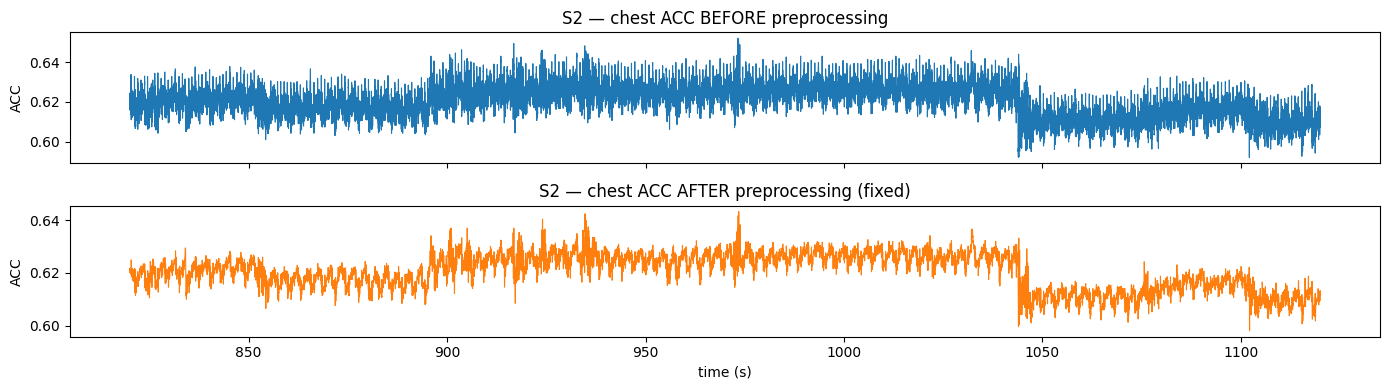

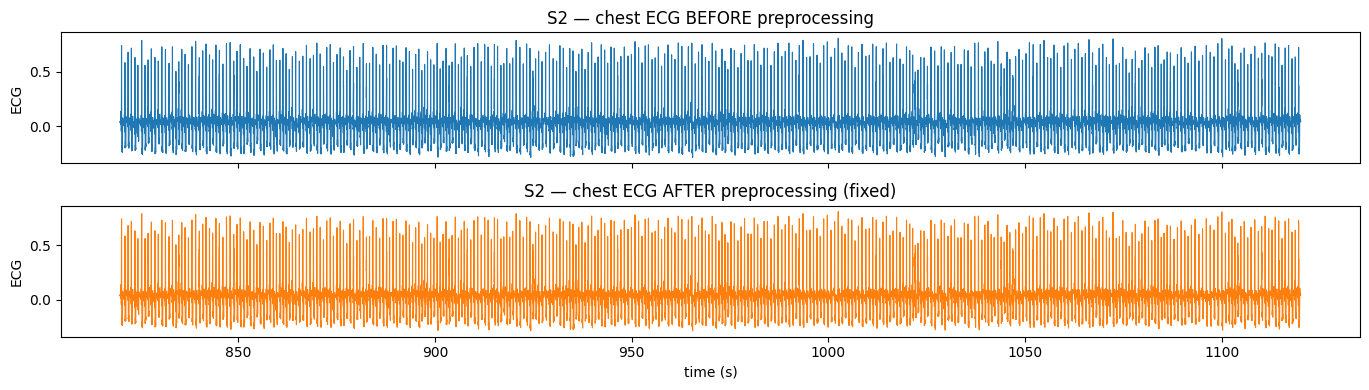

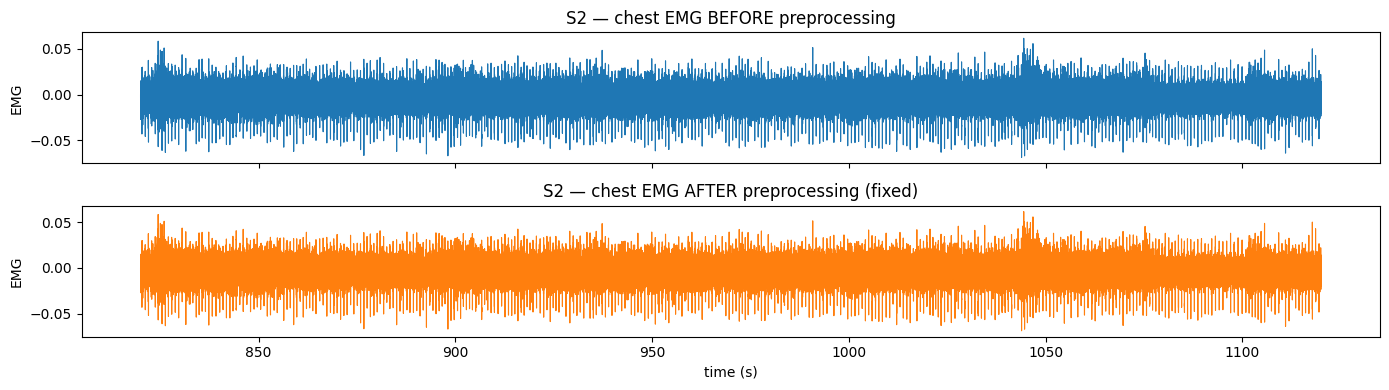

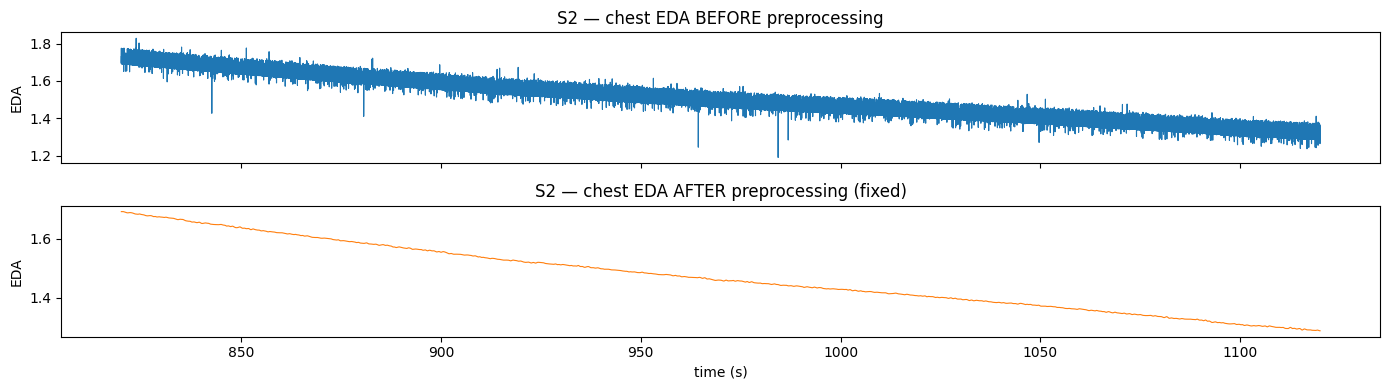

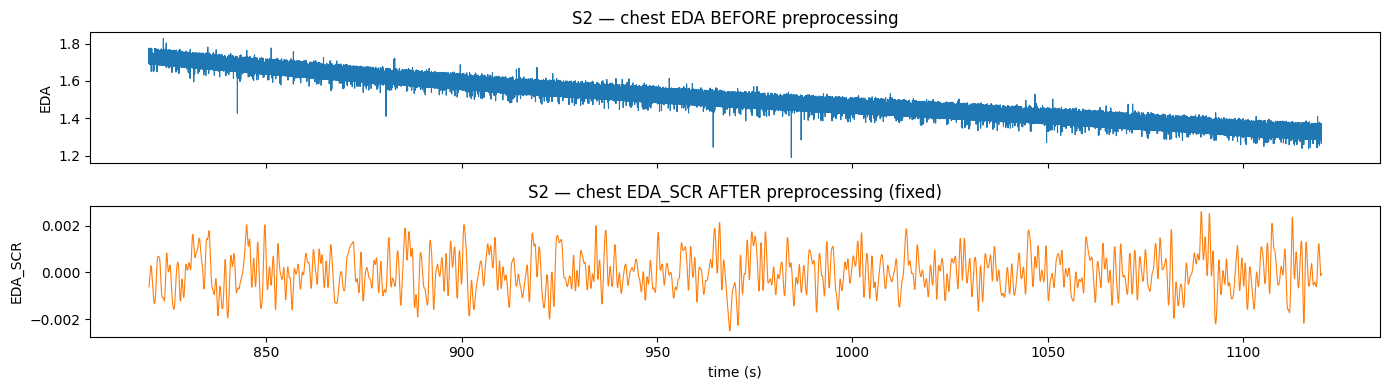

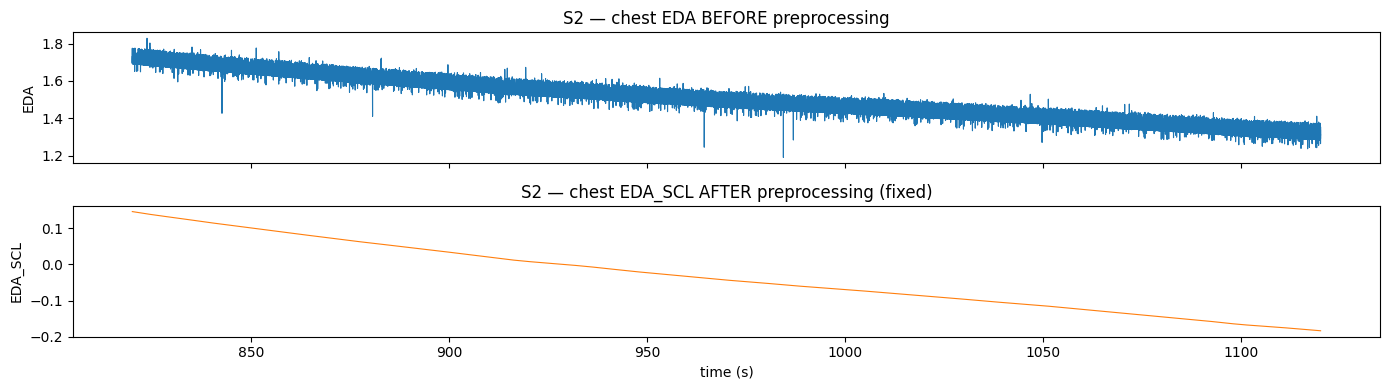

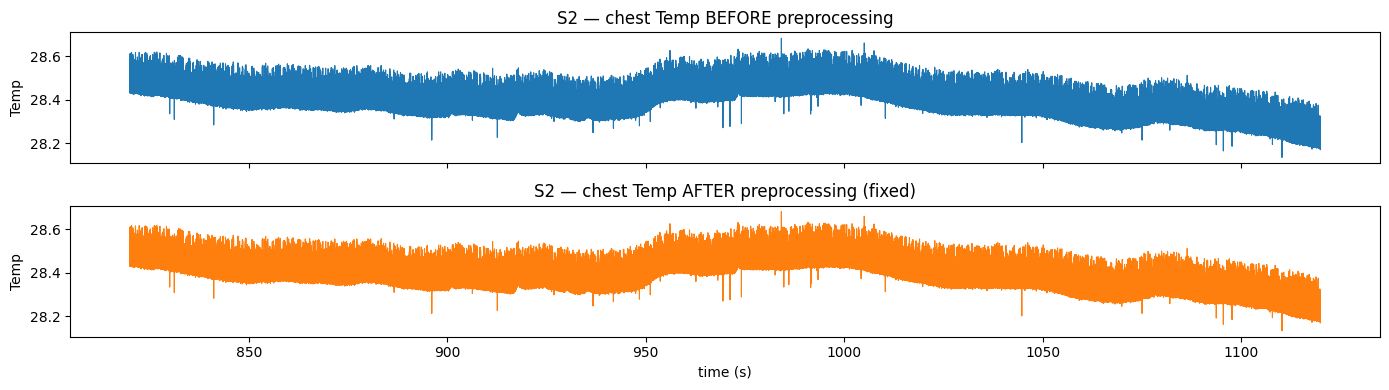

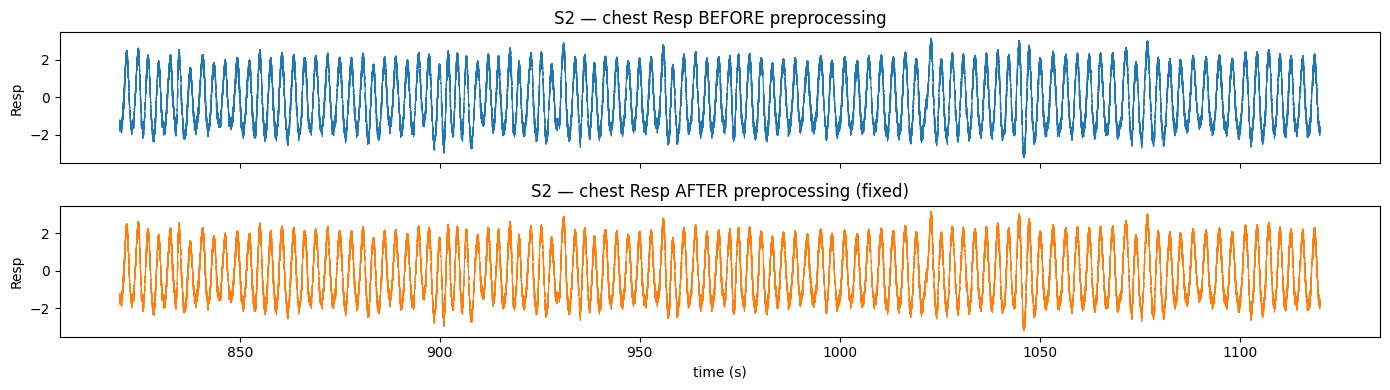

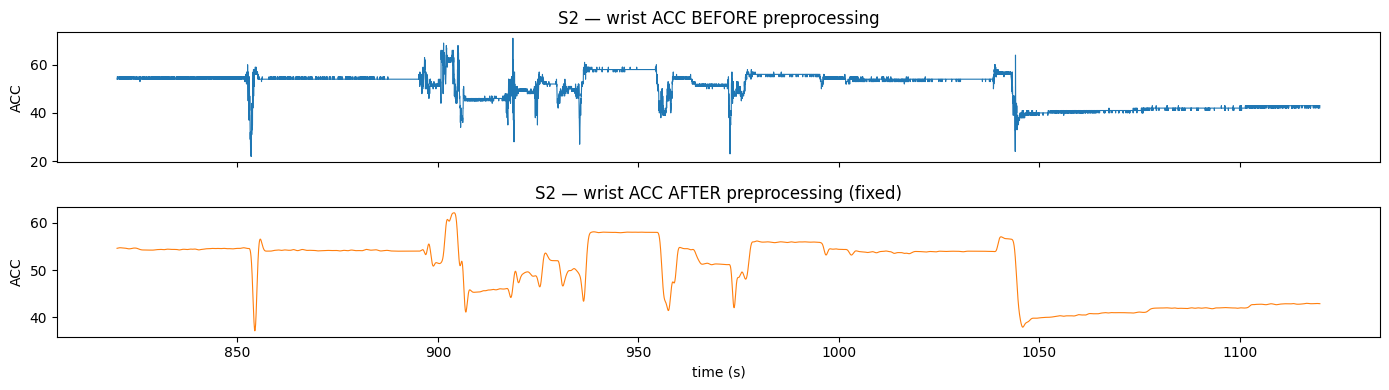

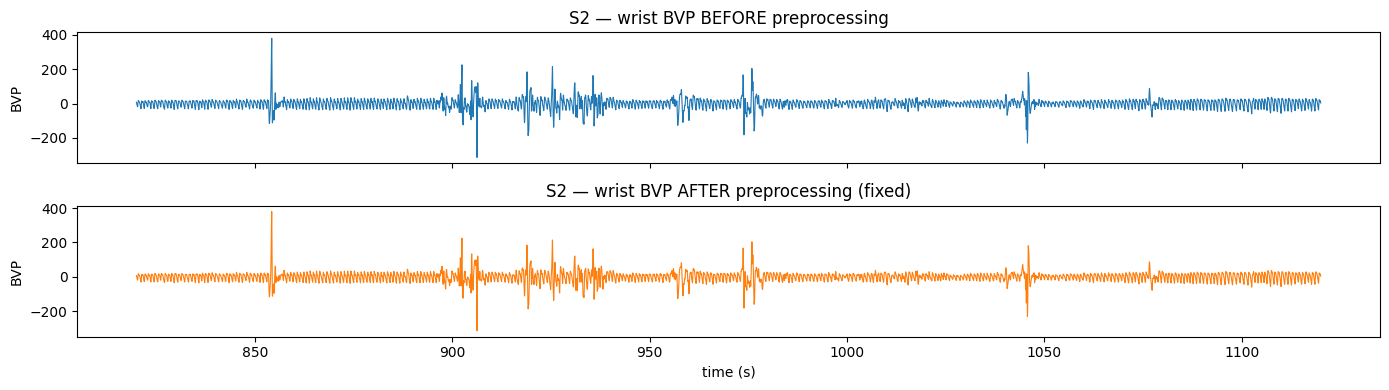

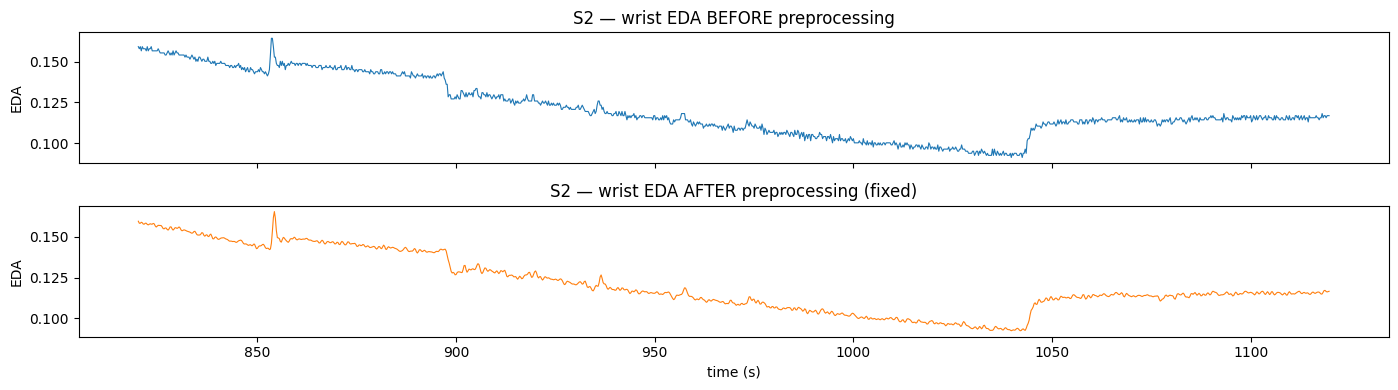

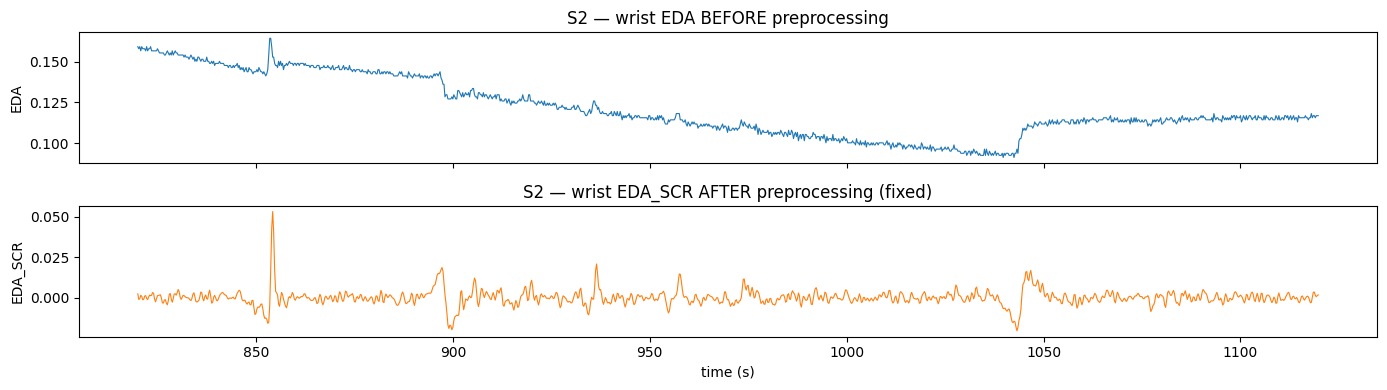

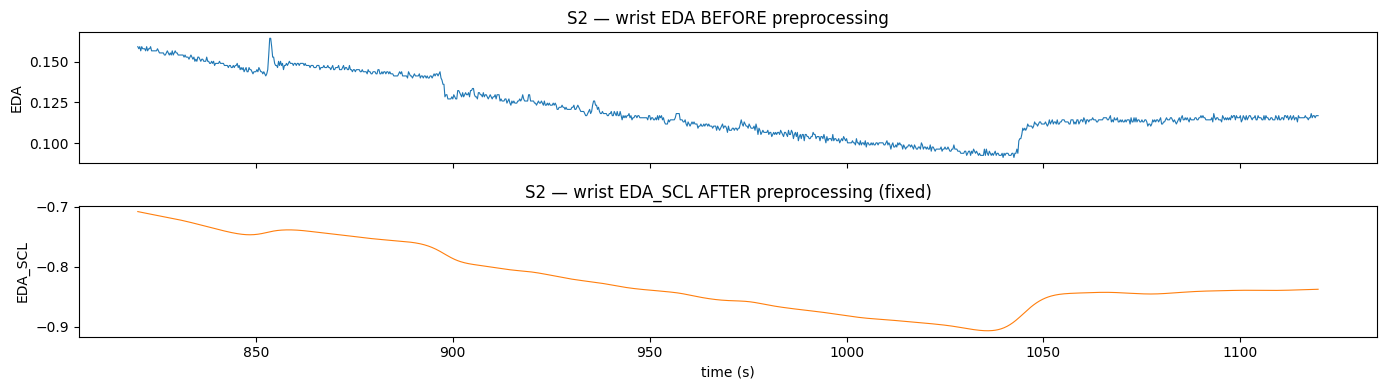

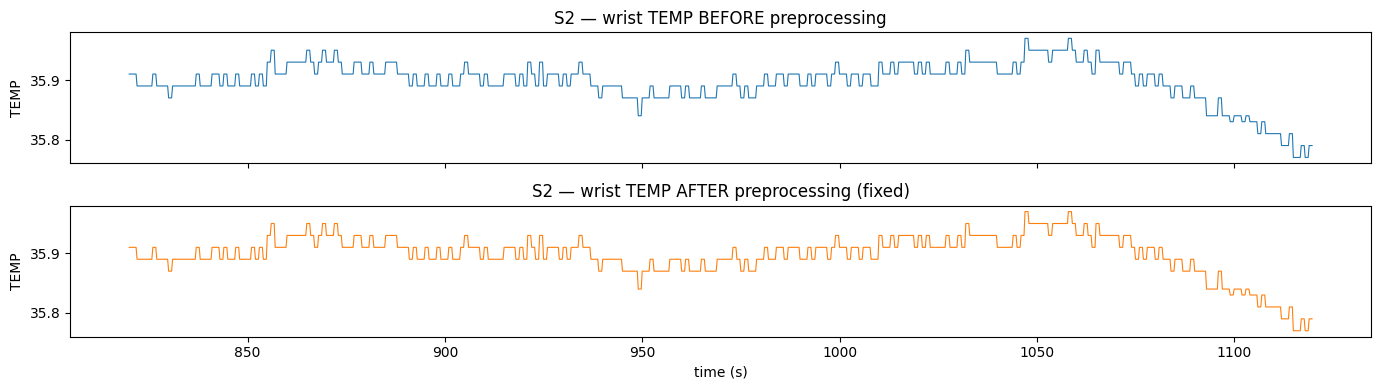

In [8]:
import matplotlib.pyplot as plt

# Before/after preview for every signal of the selected participant.
# 'Before' = raw signal from the original WESAD pkl.
# 'After'  = filtered signal from wp.filter_subject (BEFORE dropping excluded samples,
#            so the time axis is aligned with the raw signal).
filtered = wp.filter_subject(raw)

for loc in ('chest', 'wrist'):
    for name in filtered[loc]:
        fs = wp.FS[loc]['EDA' if name.startswith('EDA') else name]
        after = np.asarray(filtered[loc][name], dtype=float)

        raw_name = 'EDA' if name.startswith('EDA') else name
        before = np.asarray(raw['signal'][loc][raw_name], dtype=float)
        if before.ndim == 2 and before.shape[1] == 1:
            before = before.ravel()

        a = int(PREVIEW_START_S * fs)
        b = int((PREVIEW_START_S + PREVIEW_SECONDS) * fs)
        a, b = max(0, a), min(len(after), b)
        t = np.arange(a, b) / fs

        fig, axes = plt.subplots(2, 1, figsize=(14, 4), sharex=True)
        axes[0].plot(t, before[a:b] if before.ndim == 1 else before[a:b, 0],
                     lw=0.8, color='tab:blue')
        axes[0].set_title(f"{clean['subject']} — {loc} {raw_name} BEFORE preprocessing")
        axes[0].set_ylabel(raw_name)

        axes[1].plot(t, after[a:b] if after.ndim == 1 else after[a:b, 0],
                     lw=0.8, color='tab:orange')
        axes[1].set_title(f"{clean['subject']} — {loc} {name} AFTER preprocessing (fixed)")
        axes[1].set_ylabel(name)
        axes[1].set_xlabel('time (s)')

        plt.tight_layout()
        plt.show()
